# `fastKar` tutorial

`fastKar` is an R package for sampling and analysing **karyotype walks** through structurally-rearranged cancer genomes, plus forward-modeling Hi-C and long-read data from those karyotypes.

This notebook walks through the main user-facing functionality with a small **three-way reciprocal translocation** example: three chromosomes that have exchanged their middle segments in a 3-cycle, leaving each chromosome with one normal copy and one rearranged copy.

**Arc**:

1. Start with a small synthetic translocation graph and look at its structure.
2. Sample candidate karyotypes from the graph.
3. Forward-simulate a Hi-C map from one of the karyotypes.
4. Compute walk-to-walk distances.
5. Fit a candidate set of karyotypes to observed Hi-C data.

## Step 1 — A small three-way translocation graph

We use the synthetic constructor `make_threeway_repdup(regsize)` to build a graph corresponding to **three reciprocal translocations arranged in a 3-cycle** between chromosomes 1, 2, and 3.

- chromosomes `1, 2, 3` are each tiled into segments `{A,B,C}`, `{D,E,F}`, `{G,H,I}` of `regsize` bp
- a cyclic set of translocations links them: `chr1.B-right → chr2.E-left`, `chr2.E-right → chr3.H-left`, `chr3.H-right → chr1.B-left`
- each chromosome carries **one normal copy** and one **derivative** copy. The derivatives are `A-B-E-F` (`der1`), `D-E-H-I` (`der2`), `G-H-B-C` (`der3`)

The resulting `gGraph` has the union of normal + derivative walks as its CN profile. Each middle segment (B, E, H) appears in three walks (one normal + two derivatives), so it sits at CN = 3; outer segments (A, C, D, F, G, I) appear in two walks (one normal + one derivative) and sit at CN = 2.

In [101]:
options(warn = -1)
suppressPackageStartupMessages({
  library(Rcpp)         # fastKar's forward.R uses cppFunction at top level
  library(devtools)
  library(GxG)
  library(data.table)
})

# Loa"d Iraj's gGnome fork (provides loosefix() which fastKar's gg.to.wiring needs)
devtools::load_all("/gpfs/commons/home/ieshghi/git/gGnome", quiet = TRUE)
suppressPackageStartupMessages({
  library(skitools)
  library(gTrack)
})
# Load fastKar from the working tree
devtools::load_all("/gpfs/commons/groups/imielinski_lab/projects/agenome/fastKar",
                   quiet = TRUE)

cat("fastKar loaded.\n")

fastKar loaded.


In [105]:
set.seed(42)
gw <- make_threeway_repdup(regsize = 1e6)
gg <- gw$graph
gg

gGraph with 9 nodes, 6 loose ends (6 terminal and 0 internal), and 9 edges (6 REF and 3 ALT)
 comprising:


gNode object of length 9

... (5 additional nodes)



gEdge object with 9 edges

... (5 additional edges)



GRanges object with 4 ranges and 11 metadata columns:
    seqnames          ranges strand | udnode.id loose.left loose.right
       <Rle>       <IRanges>  <Rle> | <integer>  <logical>   <logical>
  1        1       1-1000000      + |         1       TRUE       FALSE
  2        1 1000001-2000000      + |         2      FALSE       FALSE
  3        1 2000001-3000000      + |         3      FALSE        TRUE
  4        2       1-1000000      + |         4       TRUE       FALSE
          label        cn    grl.ix   grl.iix parent.graph   node.id  snode.id
    <character> <numeric> <numeric> <numeric>    <numeric> <integer> <numeric>
  1           A         2         5         2            5         1         1
  2           B         3        11         7           11         2         2
  3           C         2         7         7            7         3         3
  4           D         2         7         2            7         4         4
        index
    <integer>
  1         1
  2 

### Inspect the graph structure

A `gGraph` exposes two main tables: `nodes` (reference intervals with their copy numbers) and `edges` (the junctions, both reference adjacencies `REF` and structural variants `ALT`).

In [129]:
suppressWarnings({
  cat("=== Nodes ===\n")
  print(gg$nodes$dt[, .(node.id, seqnames, start, end, cn)])
  cat("\n=== Edges ===\n")
  print(gg$edges$dt[, .(edge.id, type, n1, n1.side, n2, n2.side, cn)])
})

=== Nodes ===
   node.id seqnames   start     end    cn
     <int>   <fctr>   <int>   <int> <num>
1:       1        1       1 1000000     2
2:       2        1 1000001 2000000     3
3:       3        1 2000001 3000000     2
4:       4        2       1 1000000     2
5:       5        2 1000001 2000000     3
6:       6        2 2000001 3000000     2
7:       7        3       1 1000000     2
8:       8        3 1000001 2000000     3
9:       9        3 2000001 3000000     2

=== Edges ===
   edge.id   type    n1 n1.side    n2 n2.side    cn
     <num> <char> <int>  <char> <int>  <char> <num>
1:       1    REF     1   right     2    left     2
2:       2    REF     2   right     3    left     2
3:       3    REF     4   right     5    left     2
4:       4    REF     5   right     6    left     2
5:       5    REF     7   right     8    left     2
6:       6    REF     8   right     9    left     2
7:       7    ALT     2   right     5    left     1
8:       8    ALT     5   right     8    

A few observations to ground us before sampling:

- **Nine 1 Mb segments across three chromosomes (1, 2, 3)**. Outer segments (A, C, D, F, G, I) sit at CN = 2; the three middle segments (B, E, H) sit at CN = 3 because each appears in one normal walk plus two derivatives.
- **Six `REF` (reference) adjacencies** stitching the normal backbones (`A→B→C`, `D→E→F`, `G→H→I`), all at CN = 2 (each used by the corresponding normal walk *and* one derivative).
- **Three `ALT` (novel) junctions**, all at CN = 1, forming a directed cycle of translocations: `B-right → E-left → H-left → B-left → ...` — i.e. each middle segment's right side splices into the next middle segment's left side.
- **Six loose ends**, the un-rearranged chromosomal termini (two per chromosome).

Junction balance at each node leaves the sampler with freedom to choose, at every duplicated node copy, which incoming adjacency pairs with which outgoing one. The middle nodes (CN = 3) have the most choice; the outer nodes (CN = 2 with a loose-end side and a single-edge side) have effectively no freedom. So the karyotype space is determined almost entirely by what happens at B, E, and H — which is exactly the locus of the translocations.

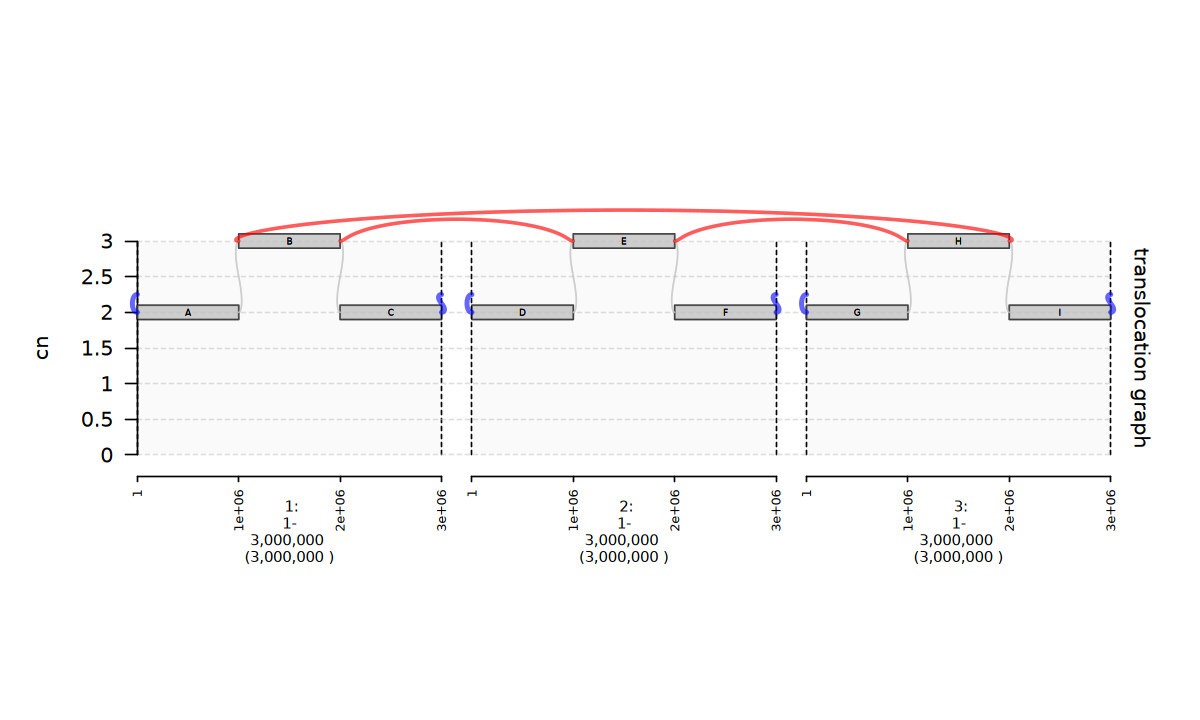

In [132]:
options(repr.plot.width = 10, repr.plot.height = 6)
suppressWarnings(plot(gg$gtrack(name = "translocation graph", y.field = "cn"),
                      gg$footprint))

**Reading the plot.** Outer segments (A, C, D, F, G, I) sit at CN = 2; the three middle segments (B, E, H) sit at CN = 3 — that's the stepped grey profile. The blue brackets at the chromosome ends are the six loose ends. The red arcs are the three novel **translocation junctions** wiring `B → E → H → B` cyclically (each pair of chromosomes is joined by exactly one translocation).

What this graph leaves under-determined is the **walk-set decomposition** at the middle nodes B, E, H — which copy of each is the "normal-flanked" one and which one carries the translocation. Step 2 samples the alternatives.

---

This completes **Step 1**. The graph object `gg` is the substrate for everything that follows: sampling, forward-modeling, distance computation, and fitting.

## Step 2 — Sampling karyotypes from the graph

A **karyotype** here is a partition of the (CN-replicated) edge set into a set of *walks* — linear or circular paths through copies of the graph nodes. Equivalently: at every node we make `cn(v)` copies, and at each copy we decide which incident edge enters from the left and which exits on the right. The graph and its CN annotations constrain the *set* of edge incidences at each node-copy (junction balance); the karyotype is what's left to choose — the **pairing**.

The size of that pairing space — the wiring count — is

$$\#\,\text{wirings} = \prod_v \mathrm{cn}(v)!$$

For our translocation graph, that's `(2!)^6 × (3!)^3 = 64 × 216 = 13 824` raw wirings. Many of those collapse to the same karyotype under reverse-complementation, multiset reordering of walks, and cyclic rotation of circular walks. As we'll see, after canonicalization only a handful of distinct karyotypes remain.

`sample.gwalks(gg, N)` draws `N` samples uniformly from the wiring space, traverses each into a set of walks, canonical-hashes them, and returns the unique karyotypes (or, with `remove.dups = FALSE`, all `N` raw samples).

In [130]:
# Draw 500 samples, dedup, return walk-list form (snode.id + circular)
set.seed(1)
walks <- sample.gwalks(gg, N = 500,
                        return.gw    = FALSE,
                        remove.dups  = TRUE,
                        verbose      = FALSE,
                        mc.cores     = 1)

cat(sprintf("Drew 500 samples; %d unique karyotypes.\n", length(walks)))
cat(sprintf("First sample has %d walks (%d linear, %d circular).\n",
            length(walks[[1]]$snode.id),
            sum(!walks[[1]]$circular),
            sum(walks[[1]]$circular)))

Drew 500 samples; 8 unique karyotypes.


First sample has 6 walks (6 linear, 0 circular).


**Saturation.** Already at `N = 500` we hit only **8 unique karyotypes** — many duplicate samples. To check whether the population really *is* that small, push to `N = 100, 500, 2000, 10000` and see whether the unique count plateaus or keeps climbing.

       N n_unique seconds
   <num>    <int>   <num>
1:   100        8   0.088
2:   500        8   0.117
3:  2000        8   0.206
4: 10000        8   0.679


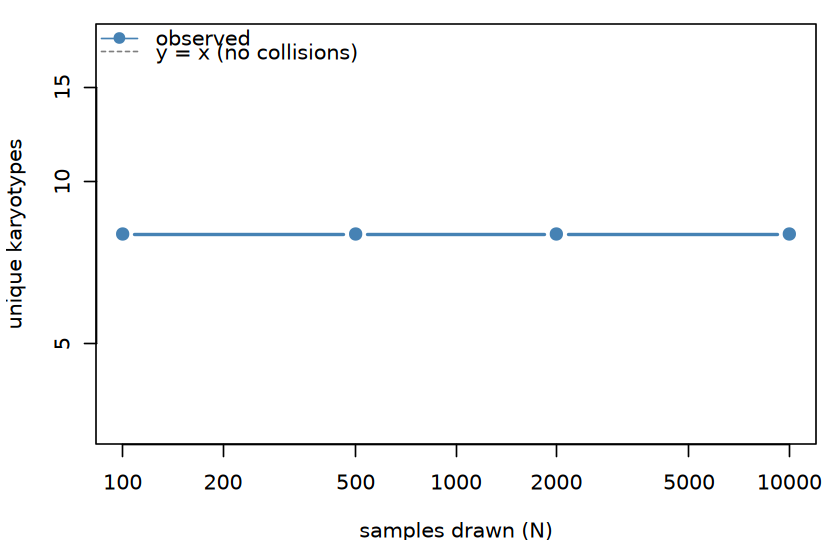

In [131]:
Ns <- c(100, 500, 2000, 10000)
sat <- data.table(N = Ns, n_unique = NA_integer_, seconds = NA_real_)
for (i in seq_along(Ns)) {
  set.seed(1)
  t <- system.time(
    w <- sample.gwalks(gg, N = Ns[i],
                        return.gw   = FALSE, remove.dups = TRUE,
                        verbose     = FALSE, mc.cores    = 1)
  )["elapsed"]
  sat[i, `:=`(n_unique = length(w), seconds = round(unname(t), 3))]
}
print(sat)

options(repr.plot.width = 7, repr.plot.height = 4.5)
par(mar = c(4, 4, 1, 1))
plot(sat$N, sat$n_unique, log = "xy", type = "b", pch = 19,
     xlab = "samples drawn (N)", ylab = "unique karyotypes",
     col  = "steelblue", lwd = 2)
abline(0, 1, lty = 2, col = "grey50")
legend("topleft", c("observed", "y = x (no collisions)"),
       col = c("steelblue", "grey50"), pch = c(19, NA), lty = c(1, 2), bty = "n")

### A single karyotype, up close

`sample.gwalks(..., return.gw = TRUE)` wraps each sampled karyotype as a `gWalk` object — a gGnome class that knows about its underlying graph and can be plotted, queried, and edited. Below are all 8 unique karyotypes side by side, each visualized as a CN-coloured trace through the underlying graph. Each karyotype is a set of 6 linear walks (3 normal + 3 derivative-like chromosomes) — together they cover every node-copy in the graph exactly once.

In [133]:
# Since the karyotype space is only 8 elements, grab all of them
set.seed(1)
walks_gw <- sample.gwalks(gg, N = 500,
                          return.gw    = TRUE,
                          remove.dups  = TRUE,
                          verbose      = FALSE,
                          mc.cores     = 1)

cat(sprintf("Got %d unique gWalk objects (the full karyotype space):\n", length(walks_gw)))
for (i in seq_along(walks_gw)) {
  w <- walks_gw[[i]]
  cat(sprintf("  [%d] %d walks (linear=%d, circular=%d), total length = %d node-copies\n",
              i,
              length(w$snode.id),
              sum(!w$circular),
              sum(w$circular),
              sum(vapply(w$snode.id, length, integer(1)))))
}
cat("\nKaryotype 1, walks (signed node ids):\n")
walks_gw[[1]]$snode.id

Got 8 unique gWalk objects (the full karyotype space):


  [1] 6 walks (linear=6, circular=0), total length = 21 node-copies
  [2] 6 walks (linear=6, circular=0), total length = 21 node-copies
  [3] 6 walks (linear=6, circular=0), total length = 21 node-copies
  [4] 6 walks (linear=6, circular=0), total length = 21 node-copies
  [5] 6 walks (linear=6, circular=0), total length = 21 node-copies
  [6] 6 walks (linear=6, circular=0), total length = 21 node-copies
  [7] 6 walks (linear=6, circular=0), total length = 21 node-copies
  [8] 7 walks (linear=6, circular=1), total length = 21 node-copies



Karyotype 1, walks (signed node ids):


[[1]]
[1] 1 2 5 8 9

[[2]]
[1] 1 2 3

[[3]]
[1] 4 5 6

[[4]]
[1] 4 5 6

[[5]]
[1] 7 8 9

[[6]]
[1] 7 8 2 3

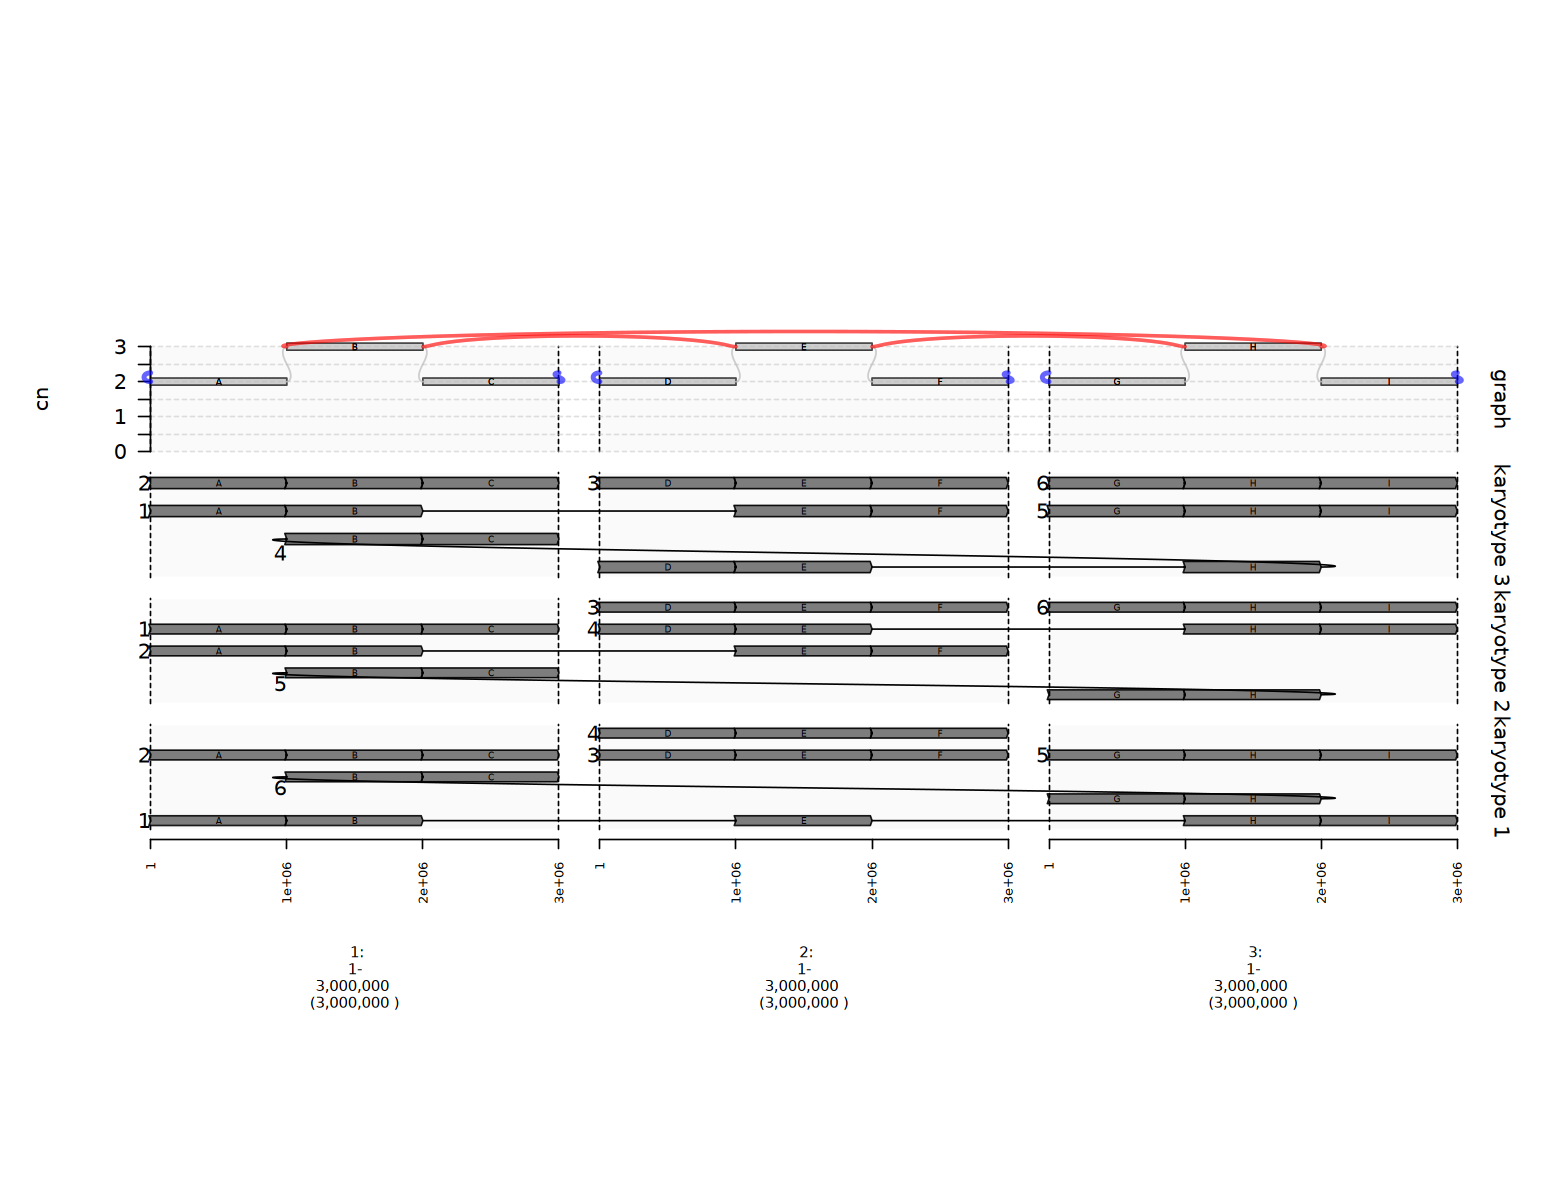

In [134]:
options(repr.plot.width = 13, repr.plot.height = 10)
suppressWarnings(
  plot(c(walks_gw[[1]]$gtrack(name = "karyotype 1"),
         walks_gw[[2]]$gtrack(name = "karyotype 2"),
         walks_gw[[3]]$gtrack(name = "karyotype 3"),
         gg$gtrack(name = "graph", y.field = "cn")),
       gg$footprint)
)

**Reading the plot.** The top track is the underlying translocation graph (from Step 1). Each lower panel is one sampled karyotype, with its walks stacked vertically. Thin black lines crossing between chromosomes mark the translocation breakpoints; the order in which the duplicated middle segments (B, E, H) get assigned to "normal" vs "derivative" walks is what differs from karyotype to karyotype.

Three things worth noting:

1. **All 8 karyotypes use the same multiset of edges.** They differ in *which* edge attaches to *which* copy at the duplicated nodes (segments B, E, H) — i.e. in the wiring.
2. **Each karyotype routes the translocation cycle through the duplicated copies differently.** Most produce six linear chromosomes (three normal + three derivatives); one of the 8 closes the B→E→H→B cycle into a small **circular** walk, leaving the chromosomes otherwise intact.
3. **Total length is conserved at 21 node-copies** (= 6 outer × CN 2 + 3 middle × CN 3). Junction balance enforces this.

This is the central ambiguity `sample.gwalks` exposes. In the next steps we'll see how Hi-C (Step 3) and walk-to-walk distances (Step 4) make these distinctions observable.

In [112]:
suppressPackageStartupMessages(library(GxG))
cat("GxG loaded; gM() now available.\n")

GxG loaded; gM() now available.


## Step 3 — Forward-simulating Hi-C from a karyotype

Step 2 left us with a population of candidate karyotypes that all explain the same CN profile equally well. To start telling them apart, we need a *forward model* — something that takes a karyotype and predicts an experimentally observable readout. `forward_simulate` does exactly this for Hi-C and long-read sequencing.

The Hi-C model is straightforward in spirit: for each pair of genomic positions, compute the expected interaction count under the assumption that contacts scale with **linear distance along the karyotype walk**, not along the reference. So a junction that brings two distant reference positions into adjacency in the walk produces a strong off-diagonal Hi-C signal — that's the rearrangement-induced "X" pattern that's visible in real cancer Hi-C.

Key parameters:

- `walks` — a `gWalk` (or `list(graph, snode.id, circular)`)
- `target_region` — `GRanges` to simulate over (defaults to walk footprint)
- `pix.size` — bin resolution in bp (default 100 kb)
- `depth` — simulated coverage depth (defaults to 1×)
- `model = 0` — Hi-C; non-zero gives long-read coverage at the given read length
- `if.interchr` — include interchromosomal contacts (TRUE)

Returns a `gMatrix` (i.e. a 2D `gTrack`-compatible object).

In [135]:
# Simulate Hi-C from karyotype 1 at 100 kb resolution
sim1 <- forward_simulate(walks_gw[[1]],
                          pix.size = 1e5,
                          depth    = 1,
                          model    = 0,
                          mc.cores = 1)

cat(sprintf("Returned class: %s\n", paste(class(sim1), collapse = ", ")))
cat(sprintf("Map dimensions:  %d bins (%d x %d contact pairs)\n",
            length(sim1$gr), nrow(sim1$dat), nrow(sim1$dat)))
cat("\nFirst few non-zero pixels:\n")
print(head(sim1$dat[order(-value)], 6))

Returned class: gMatrix, R6


Map dimensions:  90 bins (4095 x 4095 contact pairs)



First few non-zero pixels:


       i     j    value    id
   <int> <int>    <num> <int>
1:    11    11 111.5017   856
2:    12    12 111.5017   936
3:    13    13 111.5017  1015
4:    14    14 111.5017  1093
5:    15    15 111.5017  1170
6:    16    16 111.5017  1246


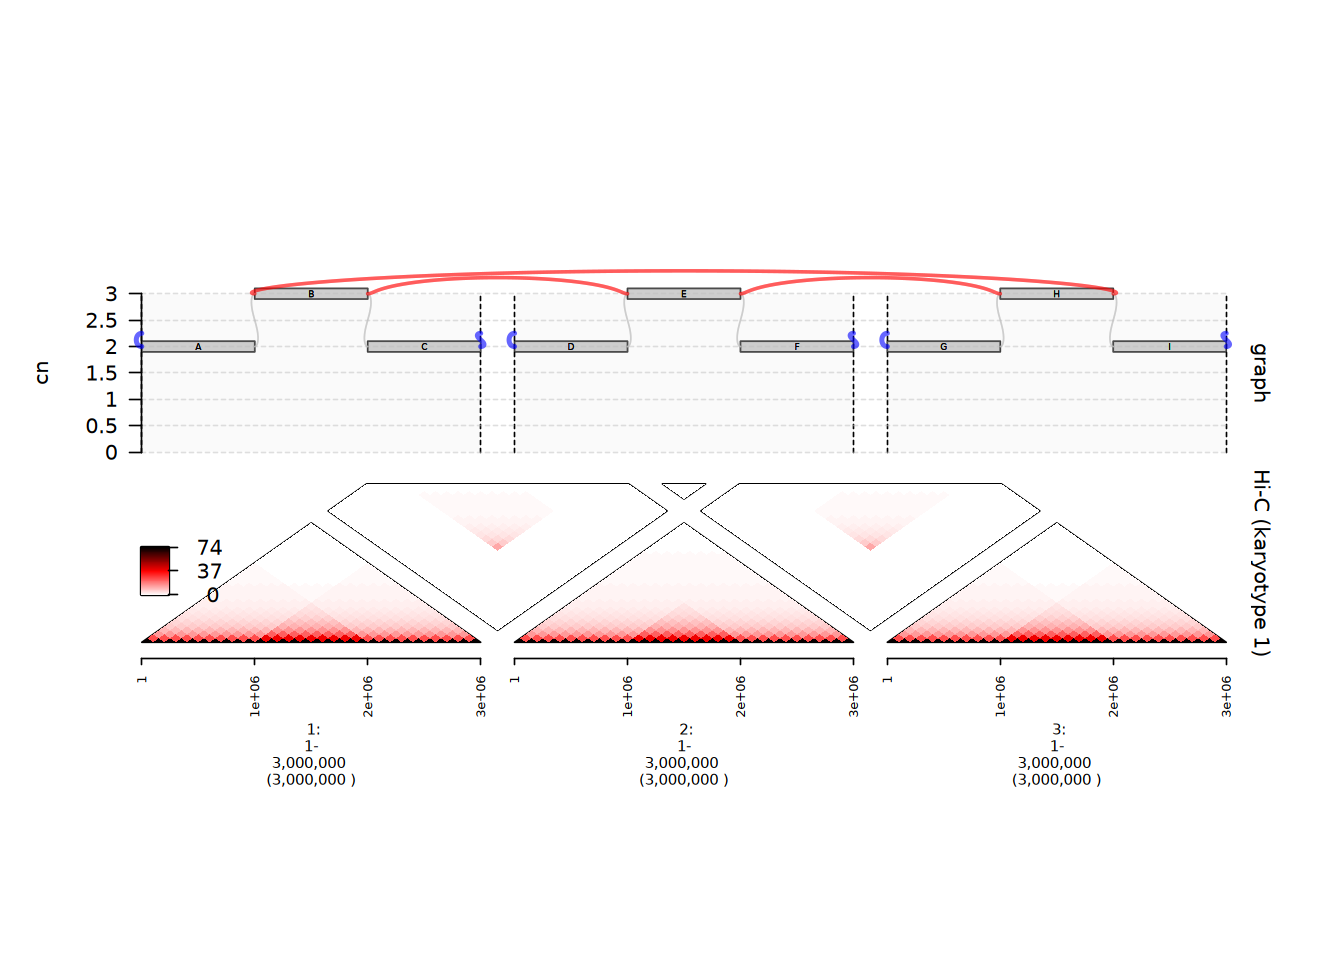

In [136]:
options(repr.plot.width = 11, repr.plot.height = 8)
suppressWarnings(
  plot(c(sim1$gtrack(name = "Hi-C (karyotype 1)"),
         gg$gtrack(name = "graph", y.field = "cn")),
       gg$footprint)
)

### Do different karyotypes produce different Hi-C?

The whole point of the forward model is that it should *distinguish* karyotypes that the graph alone leaves ambiguous. Let's simulate Hi-C maps from karyotypes 1, 2, and 3 and look at them side by side. Strongest signals are on the diagonal (each region interacting with itself, weighted by copy number) but the differences live **off-diagonal** — where the walk threading produces different long-range contacts.

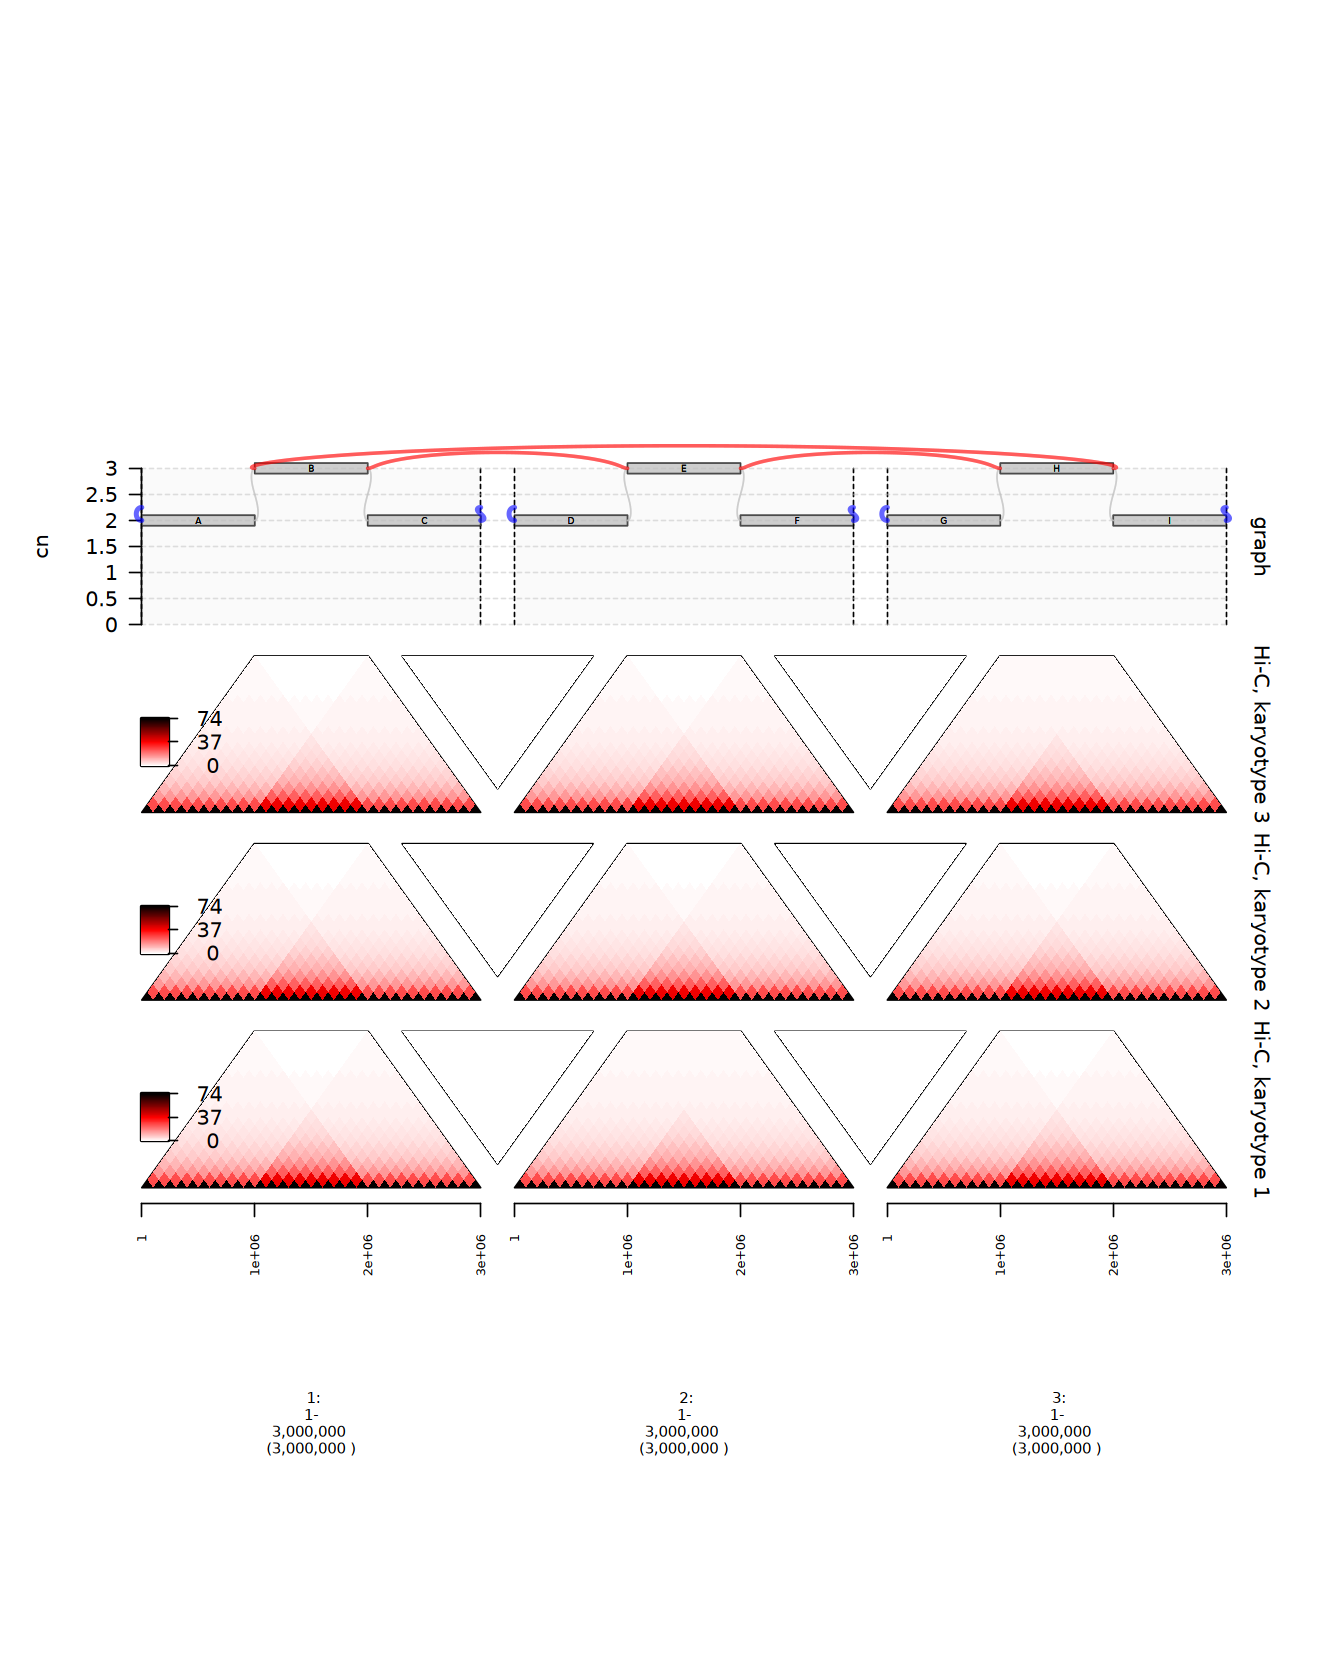

In [137]:
sims <- lapply(walks_gw[1:3], function(w) {
  forward_simulate(w, pix.size = 1e5, depth = 1, model = 0, mc.cores = 1)
})

options(repr.plot.width = 11, repr.plot.height = 14)
suppressWarnings(
  plot(c(sims[[1]]$gtrack(name = "Hi-C, karyotype 1"),
         sims[[2]]$gtrack(name = "Hi-C, karyotype 2"),
         sims[[3]]$gtrack(name = "Hi-C, karyotype 3"),
         gg$gtrack(name = "graph", y.field = "cn")),
       gg$footprint)
)

**The three maps look superficially similar** — same CN, same intra-chromosome diagonals. The discriminating signal is **off-diagonal**, specifically in the interchromosomal blocks (where row and column belong to different chromosomes), because each karyotype routes its translocation junctions through different chromosome pairs.

To make those contributions explicit, compute per-pixel differences between maps.

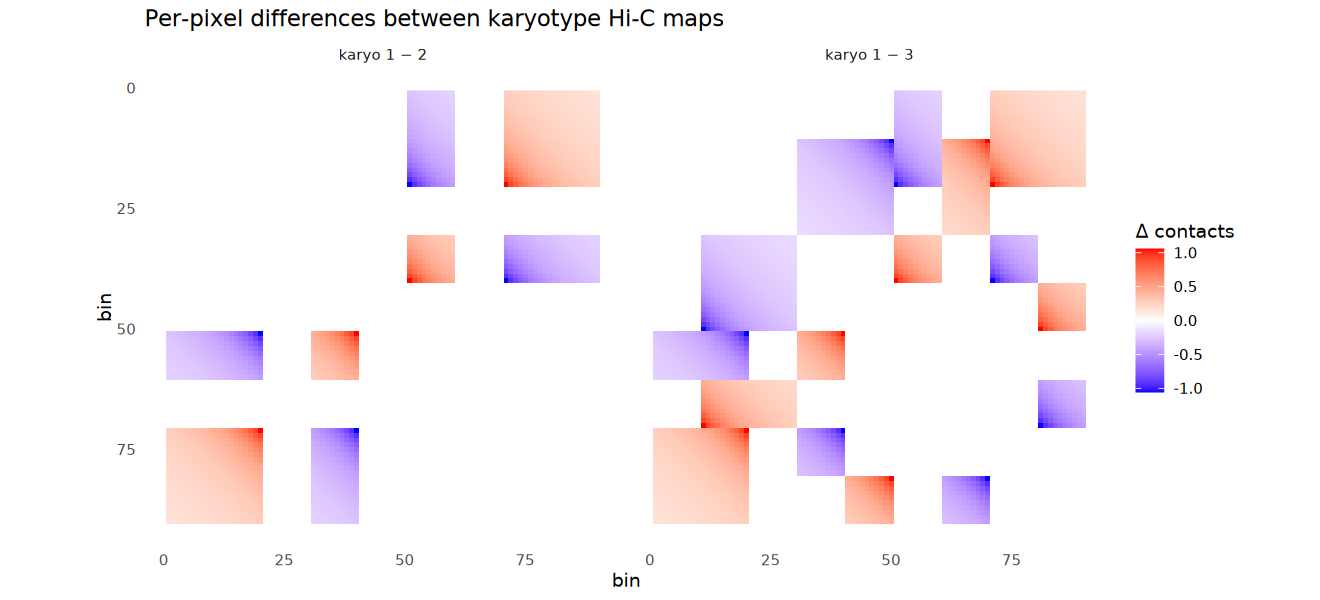

In [138]:
suppressPackageStartupMessages(library(ggplot2))

# Build long-format difference tables
make_diff_df <- function(a, b) {
  d <- as.data.table(merge(a$dat[, .(i, j, va = value)],
                           b$dat[, .(i, j, vb = value)],
                           by = c("i", "j"), all = TRUE))
  d[is.na(va), va := 0]; d[is.na(vb), vb := 0]
  d[, diff := va - vb]
  rbind(d, d[i != j, .(i = j, j = i, va, vb, diff)])  # symmetrize for display
}
d12 <- make_diff_df(sims[[1]], sims[[2]])
d13 <- make_diff_df(sims[[1]], sims[[3]])
d12[, pair := "karyo 1 − 2"]
d13[, pair := "karyo 1 − 3"]
diff_long <- rbind(d12, d13)

# Symmetric color limit so 0 is white
lim <- max(abs(diff_long$diff), na.rm = TRUE)

options(repr.plot.width = 11, repr.plot.height = 5)
ggplot(diff_long, aes(x = i, y = j, fill = diff)) +
  geom_raster() +
  scale_fill_gradient2(low = "blue", mid = "white", high = "red",
                       midpoint = 0, limits = c(-lim, lim),
                       name = "Δ contacts") +
  scale_y_reverse() +
  coord_fixed() +
  facet_wrap(~ pair) +
  labs(x = "bin", y = "bin",
       title = "Per-pixel differences between karyotype Hi-C maps") +
  theme_minimal(base_size = 11) +
  theme(panel.grid = element_blank())

Three takeaways:

1. **All differences are interchromosomal.** Intra-chromosome blocks (the empty-looking white space within each chromosome's footprint) carry zero `Δ` because both karyotypes route the same edges through the same intra-chromosomal segments. Karyotype identity *only* shows up in cross-chromosome contacts.
2. **Each Δ-block corresponds to one translocation pair.** The pattern of red/blue patches tells you which chromosome pair each karyotype joined more strongly. With three chromosomes and three middle-segment swaps, there are only a few distinguishable patterns — easy to read from the map.
3. **Magnitudes are modest but clean** (Δ ≈ ±1 contact per pixel against absolute on-diagonal values of `~70`). The differences are statistically distinguishable at any reasonable Hi-C depth.

That visual readability is the whole reason reciprocal-translocation graphs are favoured for inverse-problem demonstrations: there's enough off-diagonal "structure" to make the recovered karyotype unambiguous.

## Step 4 — Walk-to-walk distances

Step 3 showed that the karyotype space has metric structure — some sampled karyotypes are visibly close in Hi-C space, others are not. `fastKar` exposes three quantitative walk-to-walk distance measures that capture different aspects of "closeness":

| function | distance | what it measures |
|---|---|---|
| `edit_dist_cpp(gwx, gwy, graph)` | walk-set edit distance | the cost of the best Hungarian assignment between the walks of `gwx` and `gwy`, scored by Needleman-Wunsch alignment on signed `snode.id` sequences (with reverse complement). **Structural.** |
| `hic_kl(walk_x, walk_y, pix.size, depth)` | Hi-C KL | the negative-binomial KL divergence between the simulated Hi-C maps of the two karyotypes. **Observable, at a given resolution and depth.** |
| `longread_kl(walk_x, walk_y, readL)` | long-read KL | KL between the multinomials of *pseudo-reads* (windowed substrings of length `readL`) extracted from each walk. **Observable, at a given read length.** |

`get_dists(gw, graph, ...)` is the convenient wrapper that computes all three for every pair in a list of `gWalk` objects.

Each metric weights ambiguity differently. Edit distance ignores the *quantitative* contact pattern entirely; Hi-C KL is sensitive to many small differences in contact frequency; long-read KL captures local sequence-adjacency information.

In [139]:
# Pairwise distances among the three karyotypes from Step 3.
small_pairs <- data.table(i = c(1, 1, 2), j = c(2, 3, 3))
small_pairs[, `:=`(
  edit     = mapply(function(a, b) edit_dist_cpp (walks_gw[[a]], walks_gw[[b]], graph = gg), i, j),
  hic_kl   = mapply(function(a, b) hic_kl       (walks_gw[[a]], walks_gw[[b]], graph = gg,
                                                  pix.size = 1e5, depth = 1, theta = 2), i, j),
  longread = mapply(function(a, b) longread_kl  (walks_gw[[a]], walks_gw[[b]], graph = gg,
                                                  readL = 5e5, depth = 1), i, j)
)]
print(small_pairs)

       i     j  edit   hic_kl longread
   <num> <num> <num>    <num>    <num>
1:     1     2 6e+06 347.5692        0
2:     1     3 1e+07 785.3077        0
3:     2     3 6e+06 543.9494        0


In [147]:
# Same distances but with longer pseudo-reads so each spans multiple junctions
small_pairs2 <- data.table(i = c(1, 1, 2), j = c(2, 3, 3))
small_pairs2[, `:=`(
  edit       = mapply(function(a, b) edit_dist_cpp(walks_gw[[a]], walks_gw[[b]], graph = gg), i, j),
  hic_kl     = mapply(function(a, b) hic_kl     (walks_gw[[a]], walks_gw[[b]], graph = gg,
                                                 pix.size = 1e5, depth = 1, theta = 2), i, j),
  lr_kl_2Mb  = mapply(function(a, b) longread_kl(walks_gw[[a]], walks_gw[[b]], graph = gg,
                                                 readL = 2e6, depth = 1), i, j),
  lr_kl_3Mb  = mapply(function(a, b) longread_kl(walks_gw[[a]], walks_gw[[b]], graph = gg,
                                                 readL = 3e6, depth = 1), i, j)
)]
print(small_pairs2)

       i     j  edit   hic_kl lr_kl_2Mb lr_kl_3Mb
   <num> <num> <num>    <num>     <num>     <num>
1:     1     2 6e+06 347.5692  5.724585  7.434738
2:     1     3 1e+07 785.3077 16.431098 14.572413
3:     2     3 6e+06 543.9494 10.706512 10.756023


A few observations:

- **The three metrics largely agree on the qualitative ordering.** From the small table above, karyotype 1 vs 2 is the closest pair (6 Mb edit, hic_kl ≈ 348); 1 vs 3 is the most distant (10 Mb edit, hic_kl ≈ 785). The metrics tell a consistent story about which wirings are structurally similar.

- **Long-read KL depends on read length.** With 500 kb pseudo-reads (smaller than the 1 Mb tile width), most reads sit entirely inside a single segment and miss every junction; lengthening to 2 Mb introduces some discriminating power, and at 3 Mb the differences track edit distance closely. This is the long-read story for real data too: short reads see CN, long reads see local structure, *very* long reads see genome architecture.

- **Edit distance reports in base-pairs**, weighted by the node widths (the default gap penalty is `-width`). 10 Mb between karyotypes 1 and 3 means the optimal Hungarian assignment of walks leaves ~10 Mb of unmatched node-span.

Now scale up: compute pairwise distances among **all 8** karyotypes and visualize the distance matrices.

In [140]:
# Grab every distinct karyotype (we already know there are only 8)
set.seed(1)
walks_all <- sample.gwalks(gg, N = 500,
                           return.gw    = TRUE,
                           remove.dups  = TRUE,
                           verbose      = FALSE,
                           mc.cores     = 1)
cat(sprintf("Total karyotypes: %d\n", length(walks_all)))

# All pairwise distances (lower triangle)
d <- get_dists(walks_all, graph = gg,
               pix.size = 1e5, readL = 3e6, edit_thresh = 0, mc.cores = 1)
print(d)

Total karyotypes: 8


Calculating Hi-C distances



Calculating edit distances



Calculating long-read distances



        i     j       hic    edit  longread
    <int> <int>     <num>   <num>     <num>
 1:     2     1  543.9494 6.0e+06 10.756023
 2:     3     1  785.3077 1.0e+07 14.572413
 3:     4     1  240.6853 6.0e+06  7.434738
 4:     5     1  745.0366 1.0e+07 14.770455
 5:     6     1  240.6853 6.0e+06  7.434738
 6:     7     1  785.3077 1.0e+07 14.572413
 7:     8     1  280.4830 8.0e+06 11.251128
 8:     3     2  347.5692 6.0e+06  7.434738
 9:     4     2  421.6706 1.0e+07 11.251128
10:     5     2  421.6706 1.0e+07 11.251128
11:     6     2  421.6706 1.0e+07 11.251128
12:     7     2  347.5692 6.0e+06  7.434738
13:     8     2  354.2947 1.2e+07 11.449170
14:     4     3  240.6853 6.0e+06  7.434738
15:     5     3  240.6853 6.0e+06  7.434738
16:     6     3  745.0366 1.0e+07 14.770455
17:     7     3  785.3077 1.0e+07 14.572413
18:     8     3  280.4830 1.0e+07 11.251128
19:     5     4  594.2707 6.0e+06 14.572413
20:     6     4  594.2707 6.0e+06 14.572413
21:     7     4 1051.8740 1.0e+0

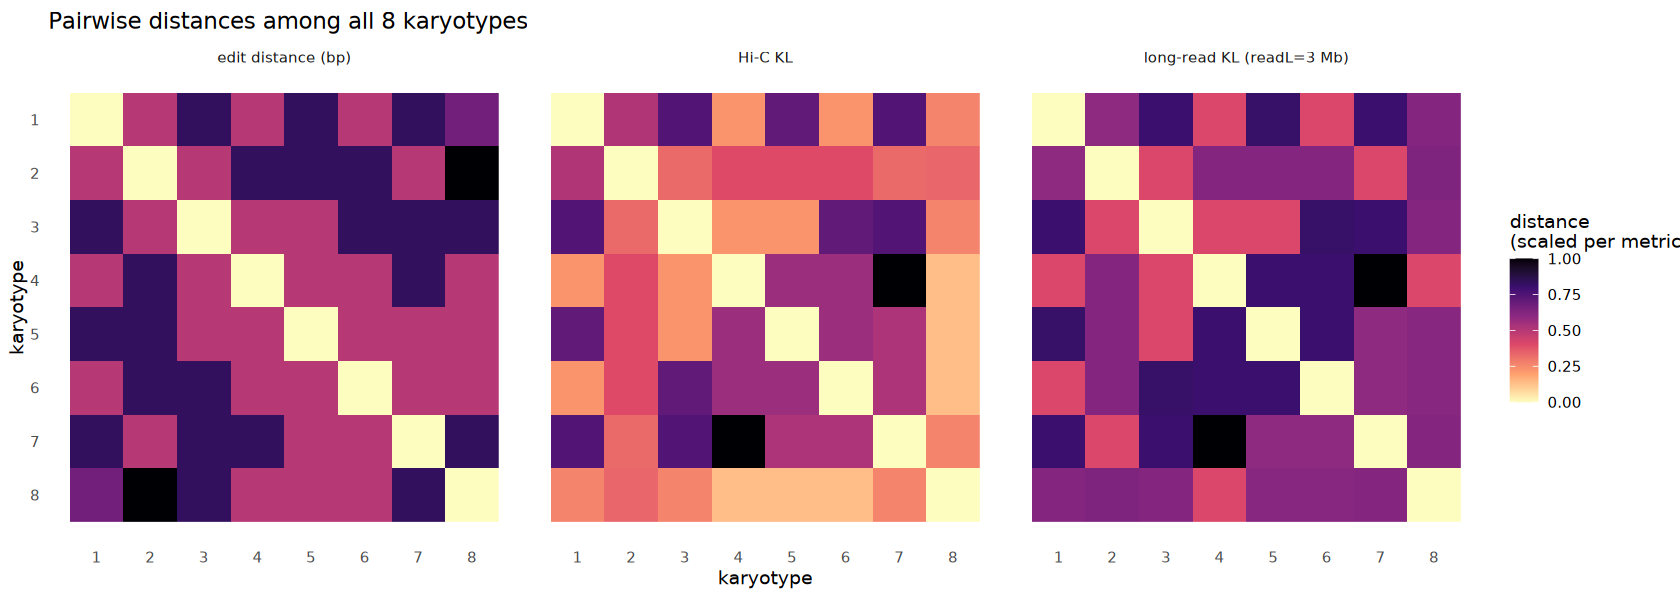

In [141]:
N <- length(walks_all)
d_sym <- rbind(
  d,
  d[, .(i = j, j = i, hic, edit, longread)],
  data.table(i = 1:N, j = 1:N, hic = 0, edit = 0, longread = 0)
)
d_long <- data.table::melt(d_sym, id.vars = c("i", "j"),
                           variable.name = "metric", value.name = "dist")
d_long[, metric := factor(metric,
                          levels = c("edit", "hic", "longread"),
                          labels = c("edit distance (bp)",
                                     "Hi-C KL",
                                     "long-read KL (readL=3 Mb)"))]
d_long[, dist_norm := dist / max(dist, na.rm = TRUE), by = metric]

options(repr.plot.width = 14, repr.plot.height = 5)
ggplot(d_long, aes(x = i, y = j, fill = dist_norm)) +
  geom_raster() +
  facet_wrap(~ metric, nrow = 1) +
  scale_x_continuous(breaks = 1:N) +
  scale_y_reverse(breaks = 1:N) +
  scale_fill_viridis_c(option = "magma", direction = -1,
                       name = "distance\n(scaled per metric)") +
  coord_fixed() +
  labs(x = "karyotype", y = "karyotype",
       title = sprintf("Pairwise distances among all %d karyotypes", N)) +
  theme_minimal(base_size = 11) +
  theme(panel.grid = element_blank(),
        legend.position = "right")

**Three views of the entire 8-karyotype space.**

- **Edit distance** (left) shows a block-like structure with most off-diagonal pairs separated by 6–12 Mb of misaligned segment span. There are two distance tiers (≈ 6 Mb vs ≈ 10–12 Mb), corresponding to "differ at one middle-segment choice" vs "differ at multiple middle-segment choices".
- **Hi-C KL** (middle) is largely consistent with edit distance but with finer gradations — it picks up *quantitative* differences in interchromosomal contact patterns. Karyotype 7 in particular is the structural outlier by Hi-C: it routes the translocation cycle through a configuration that produces strong off-diagonal Hi-C blocks.
- **Long-read KL** (right) tracks edit distance closely because long pseudo-reads (3 Mb, spanning ≥ 2 segments) directly see the local sequence adjacencies that edit-distance alignment is sensitive to.

The agreement between metrics is much stronger than in a BFB-style amplicon (where the distance measures disagreed about which karyotype was the outlier). With a discrete and small karyotype space, **the data and structural views converge**.

That's the setup for Step 5: with only 8 candidates and a clear data signal, fitting back to observed Hi-C should pinpoint a tight cluster including the truth.

## Step 5 — Fitting karyotypes to observed Hi-C

So far we've stayed inside a forward model: walk → Hi-C. The inverse problem is the practically interesting one: given an observed Hi-C dataset over a structural variant region, *which* of the many karyotypes consistent with the graph is the right one?

`bestfit_search(graph, hic, nsample, depth, ...)` is `fastKar`'s answer to this. It:

1. samples `nsample` karyotypes from the graph,
2. forward-simulates the Hi-C map for each at the requested depth/resolution,
3. scores every simulated map against the observed `hic` with `compmaps` (negative-binomial NLL),
4. returns the top-`topk` karyotypes ranked by data likelihood.

The R/backwards.R note says this part of the pipeline is **work-in-progress**; the public interface is stable but expect rough edges in the implementation.

### A controlled experiment

To make recovery checkable, we pretend: pick one sampled karyotype, declare it the **ground truth**, simulate its noiseless Hi-C, add negative-binomial sampling noise, and hand the resulting "observation" to `bestfit_search`. The question is whether the best-fitting karyotype recovers the truth (or a karyotype nearby it).

In [142]:
# Pick the "ground truth" karyotype
set.seed(99)
true_walks_l <- sample.gwalks(gg, N = 1,
                              return.gw    = TRUE,
                              remove.dups  = TRUE,
                              verbose      = FALSE,
                              mc.cores     = 1)
true_walk <- true_walks_l[[1]]
true_hash <- hash_karyotype_cpp(true_walk$snode.id, true_walk$circular)
cat(sprintf("Ground-truth karyotype: %d walks, hash = %s\n",
            length(true_walk$snode.id), true_hash))

# Noiseless and noisy Hi-C
true_hic <- forward_simulate(true_walk, pix.size = 1e5, depth = 20,
                             model = 0, mc.cores = 1)
set.seed(0)
obs_hic  <- make_noisymap(true_hic, theta = 2, num.copies = 1, mc.cores = 1)[[1]]
cat(sprintf("Simulated Hi-C: %d bins, total contacts (clean=%g  observed=%g)\n",
            length(true_hic$gr),
            sum(true_hic$dat$value),
            sum(obs_hic$dat$value)))

Ground-truth karyotype: 6 walks, hash = c5ac4014615d547c


Simulated Hi-C: 90 bins, total contacts (clean=339908  observed=345581)


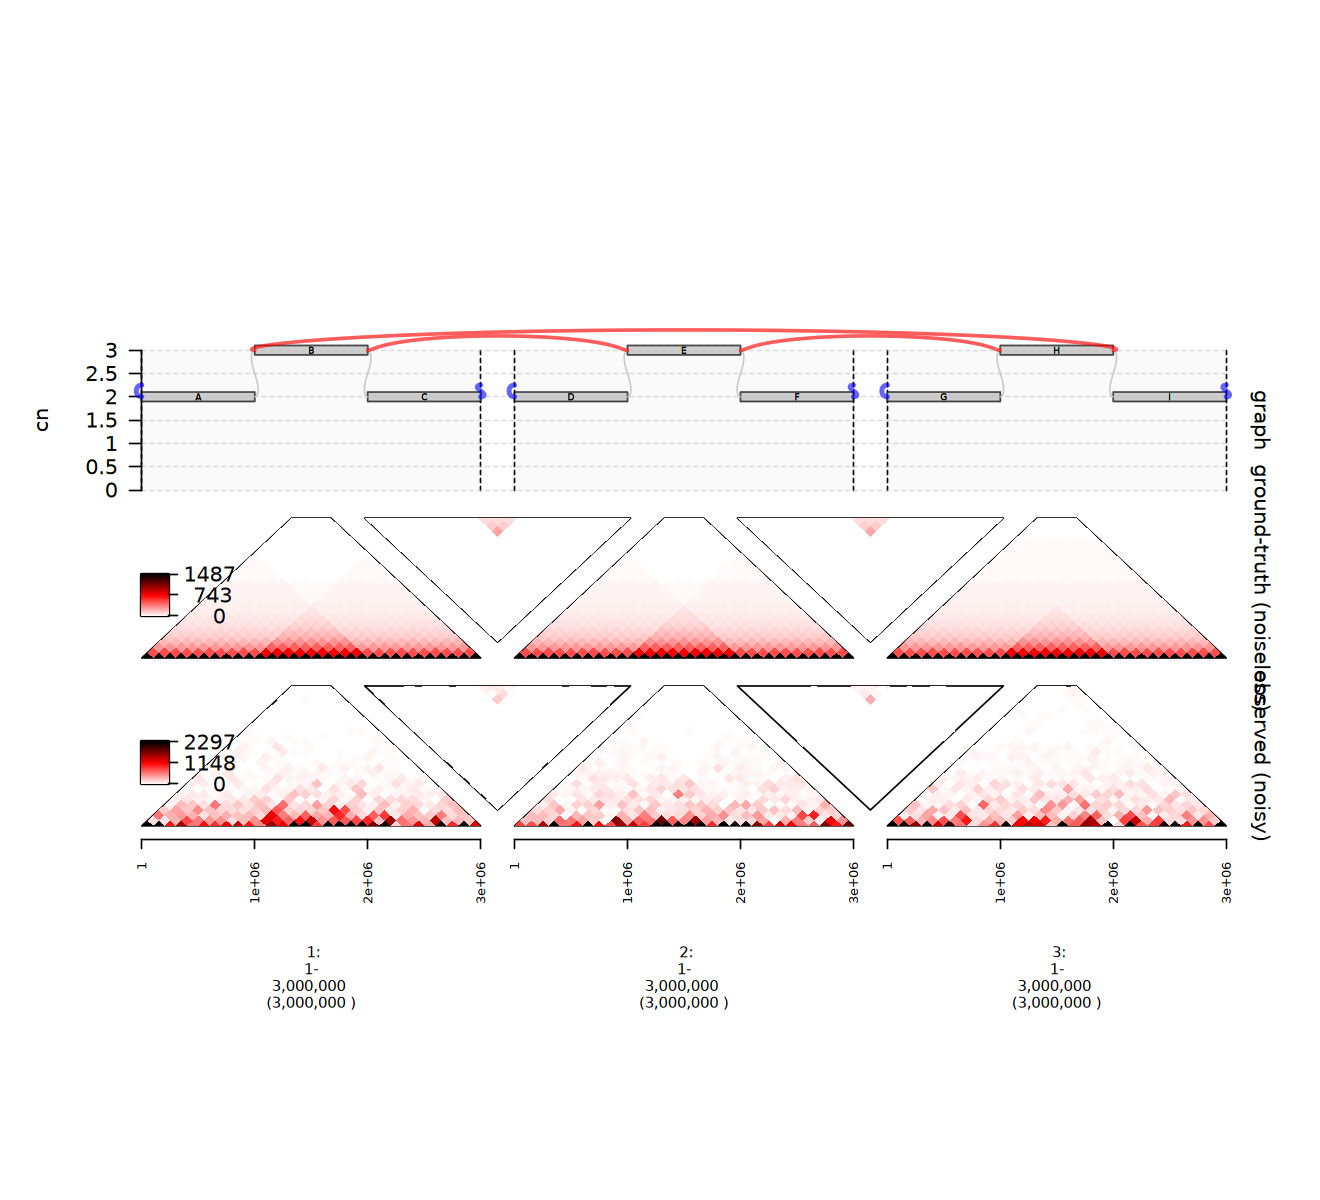

In [124]:
options(repr.plot.width = 11, repr.plot.height = 10)
suppressWarnings(
  plot(c(obs_hic$gtrack (name = "observed (noisy)"),
         true_hic$gtrack(name = "ground-truth (noiseless)"),
         gg$gtrack(name = "graph", y.field = "cn")),
       gg$footprint)
)

In [143]:
# Search candidate karyotypes against the noisy observation.
# Even nsample=50 should comfortably cover the entire 8-element space.
set.seed(7)
t_fit <- system.time({
  fit <- bestfit_search(graph         = gg,
                        hic           = obs_hic,
                        nsample       = 50,
                        depth         = 20,
                        pix.size      = 1e5,
                        target_region = gg$footprint,
                        topk          = 5,
                        mc.cores      = 1)
})["elapsed"]
cat(sprintf("bestfit_search: 50 candidates, %.1fs elapsed\n\n", t_fit))

top_hashes <- vapply(fit$walks,
                     function(w) hash_karyotype_cpp(w$snode.id, w$circular),
                     character(1))
tab <- data.table(nll     = round(fit$nll, 1),
                  hash    = top_hashes,
                  is_true = top_hashes == true_hash)
setorder(tab, nll)
tab[, rank := .I]
setcolorder(tab, c("rank", "nll", "is_true", "hash"))
print(tab)

Sampling walks



Simulating Hi-C



bestfit_search: 50 candidates, 3.9s elapsed



    rank     nll is_true             hash
   <int>   <num>  <lgcl>           <char>
1:     1 12660.4   FALSE 1915325f2b556264
2:     2 12685.7    TRUE c5ac4014615d547c
3:     3 12697.5   FALSE fd19157eb198b9cc
4:     4 12931.4   FALSE e70cde83c0e6165c
5:     5 12942.0   FALSE 175a84353349e41c


In [144]:
# NLL gap between the top fit and every other karyotype in the entire space
# (we already enumerated them as walks_all in Step 4).
all_hashes <- vapply(walks_all,
                     function(w) hash_karyotype_cpp(w$snode.id, w$circular),
                     character(1))
all_sims <- lapply(walks_all, function(w)
  forward_simulate(w, pix.size = 1e5, depth = 20, model = 0, mc.cores = 1))
all_nll <- vapply(all_sims, function(s)
  compmaps(s, obs_hic, theta = 2, ifsum = TRUE), numeric(1))

space_tab <- data.table(karyotype = seq_along(walks_all),
                        nll       = round(all_nll, 1),
                        is_true   = all_hashes == true_hash,
                        hash      = all_hashes)
setorder(space_tab, nll)
space_tab[, rank := .I]
setcolorder(space_tab, c("rank", "karyotype", "nll", "is_true", "hash"))
print(space_tab)

cat(sprintf("\nNLL gap (truth -> runner-up): %.1f\n",
            space_tab[rank == 2, nll] - space_tab[rank == 1, nll]))

    rank karyotype     nll is_true             hash
   <int>     <int>   <num>  <lgcl>           <char>
1:     1         2 12660.4   FALSE 1915325f2b556264
2:     2         3 12685.7    TRUE c5ac4014615d547c
3:     3         8 12697.5   FALSE fd19157eb198b9cc
4:     4         5 12931.4   FALSE e70cde83c0e6165c
5:     5         7 12942.0   FALSE 175a84353349e41c
6:     6         4 12971.2   FALSE dad21b2de4a24644
7:     7         1 13001.3   FALSE d3c972f6432afdfc
8:     8         6 13253.4   FALSE 3f7d45b918f8111c



NLL gap (truth -> runner-up): 25.3


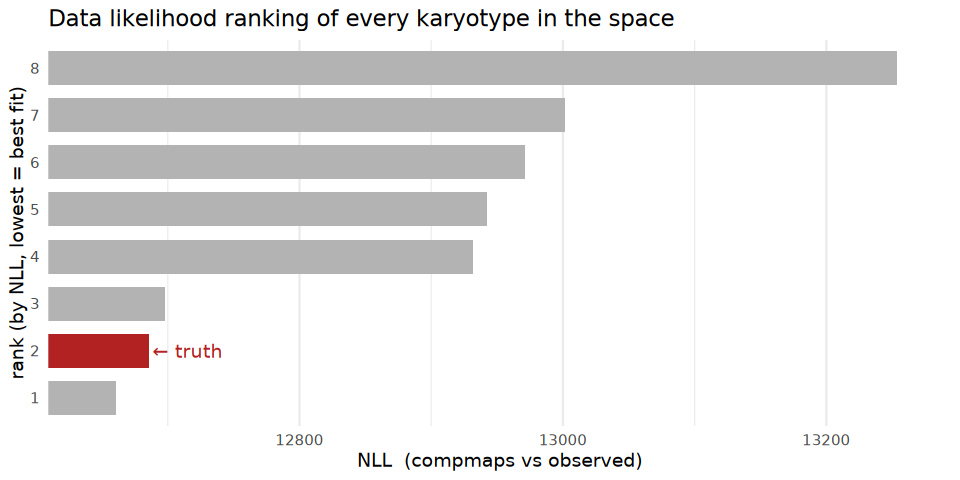

In [145]:
options(repr.plot.width = 8, repr.plot.height = 4)
ggplot(space_tab, aes(x = factor(rank), y = nll, fill = is_true)) +
  geom_col(width = 0.7) +
  geom_text(aes(label = ifelse(is_true, "← truth", "")),
            hjust = -0.05, vjust = 0.5, colour = "firebrick", size = 4) +
  scale_fill_manual(values = c("FALSE" = "grey70", "TRUE" = "firebrick"),
                    guide = "none") +
  coord_flip(ylim = c(min(space_tab$nll) - 20, max(space_tab$nll) + 10)) +
  labs(x = "rank (by NLL, lowest = best fit)", y = "NLL  (compmaps vs observed)",
       title = "Data likelihood ranking of every karyotype in the space") +
  theme_minimal(base_size = 11) +
  theme(panel.grid.major.y = element_blank())

Reading the ranking:

- **Truth lands at rank 2** — narrowly out-fit by another karyotype that, under this particular noise realization, happened to match the observed pixel pattern slightly better. The NLL margin between the best fit and truth (~25) is much smaller than the gap (~230) separating the top three karyotypes from the bottom five, so the data is clearly **localizing** truth into a tight cluster of indistinguishable-by-noise candidates.
- **The top-three karyotypes are within ~40 NLL of each other**; the other five sit ~230+ NLL further away. The data confidently rules out the bottom five but cannot resolve among the top three at this depth/resolution. Re-running with a fresh noise draw would likely reshuffle the top-three but rarely pull one of the bottom five into contention.
- **The lower-half ranking is monotonic and well-separated** — those are the karyotypes that route the translocation cycle through chromosome pairs that produce visibly different interchromosomal Hi-C structure.

This is the realistic behavior of `bestfit_search`: a clean confidence set, not a deterministic point estimate. Whether truth lands at rank 1 or rank 2 depends on the noise realization; what's robust is that truth is in the top tier.

Now let's confirm visually that the rank-1 fit's predicted Hi-C closely matches the ground-truth's.

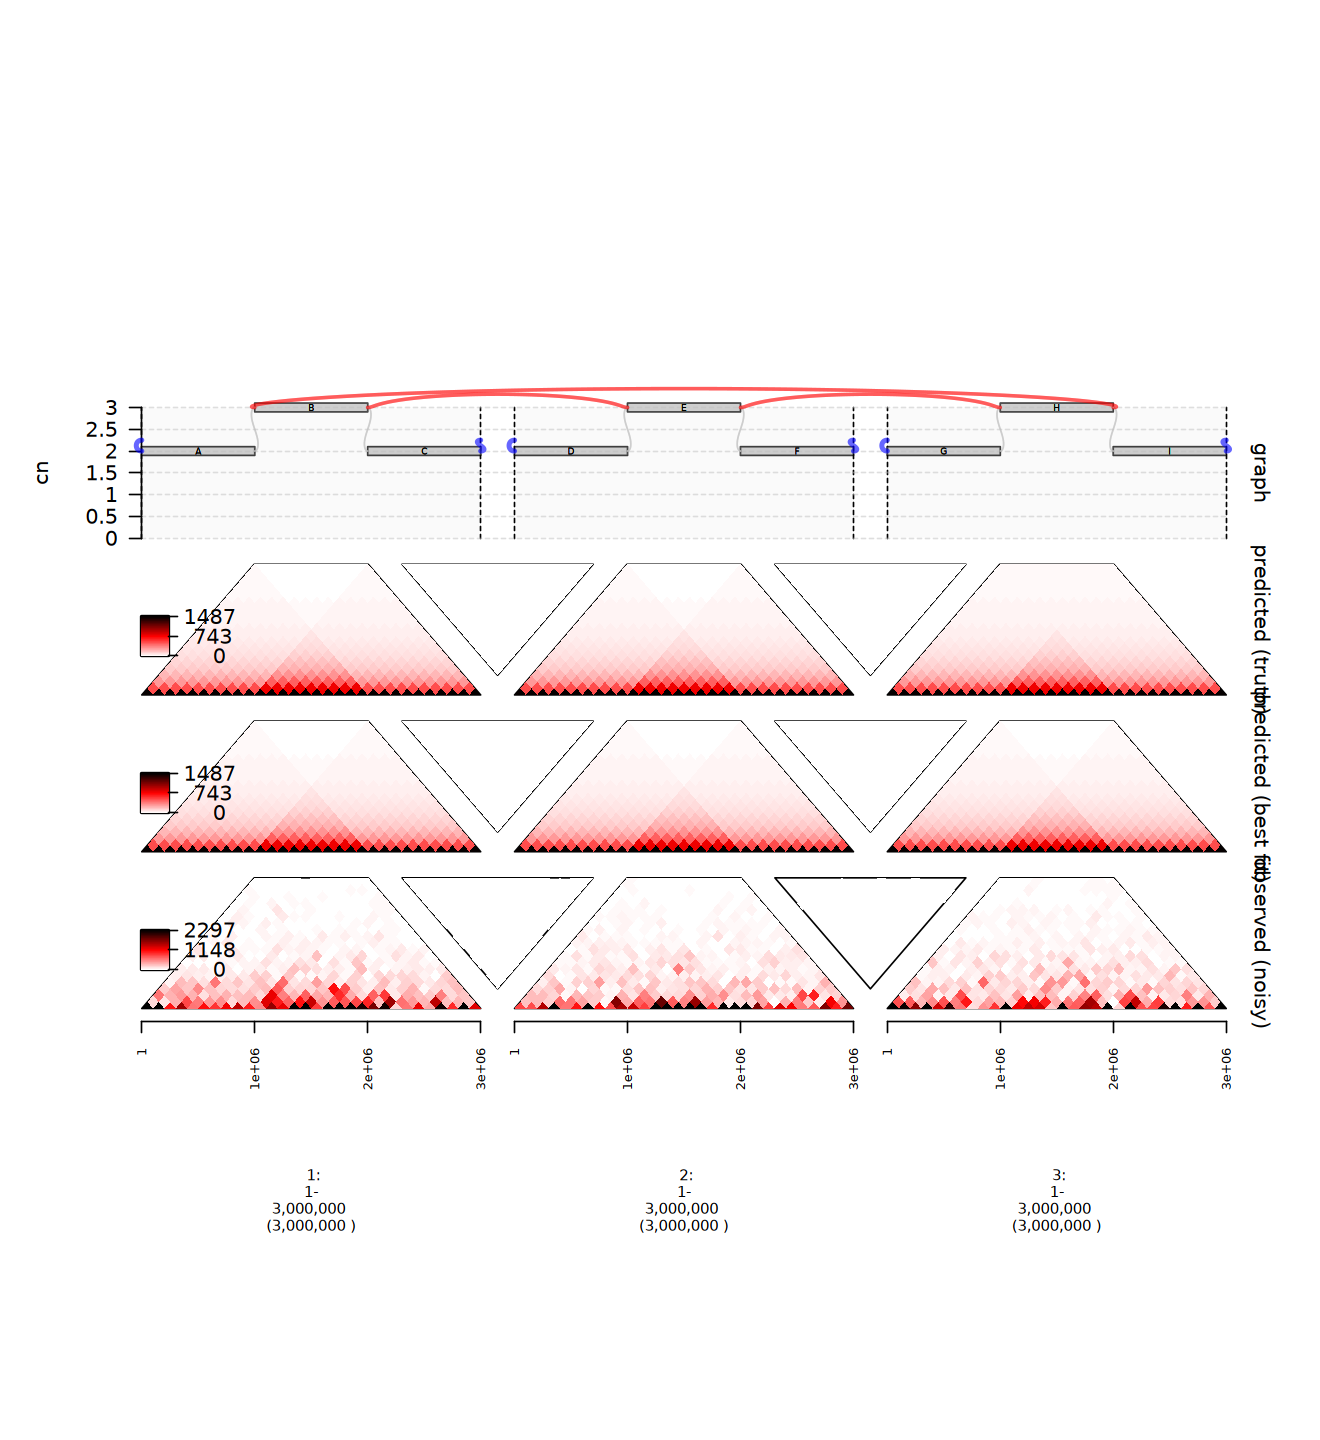

In [146]:
# Predicted Hi-C from the best fit, alongside observed (noisy) and ground truth (noiseless)
best_walk <- fit$walks[[1]]
best_hic  <- forward_simulate(best_walk, pix.size = 1e5, depth = 20,
                              model = 0, mc.cores = 1)

options(repr.plot.width = 11, repr.plot.height = 12)
suppressWarnings(
  plot(c(obs_hic $gtrack(name = "observed (noisy)"),
         best_hic$gtrack(name = "predicted (best fit)"),
         true_hic$gtrack(name = "predicted (truth)"),
         gg$gtrack(name = "graph", y.field = "cn")),
       gg$footprint)
)

**The best-fit and ground-truth predicted Hi-C look nearly identical** at this resolution — same scale, same intra-chromosome diagonals, near-identical interchromosomal blocks. Any structural difference between the rank-1 (non-truth) fit and the ground-truth lives at sub-pixel level for our 100 kb bins.

The takeaway:

- For **reciprocal translocations** like this one, every wiring choice rewrites which chromosome pair the translocated segment lands in, producing distinctive interchromosomal Hi-C contacts. The karyotype space is small (about 13,824 raw wirings, **8 unique karyotypes** after canonicalization) and easily enumerable. **The data localizes truth to within a tight cluster** — typically the top-1 or top-2 by NLL, with a clean separation from the rest of the space.
- For **BFB amplicons** (or other intra-chromosomal amplifications), wiring choices produce mostly intra-chromosomal walk threadings that look very similar in Hi-C space, the karyotype space is enormous (≥ 10,000+ unique elements), and `bestfit_search` becomes a localiser over a wider neighborhood rather than a near-point estimator.

Real cancer Hi-C will sit somewhere on this spectrum — interchromosomal SV events tend toward the identifiable end, intra-chromosomal amplicons toward the ambiguous end. The pipeline scales to both regimes: same `gGraph` input, same `sample.gwalks` + `forward_simulate` + `compmaps` machinery, just different effective cardinality.

---

This wraps up the **5-step tutorial**:

1. ✅ Construct a graph (`make_threeway_repdup`)
2. ✅ Sample karyotypes from it (`sample.gwalks`)
3. ✅ Forward-simulate Hi-C from a karyotype (`forward_simulate`)
4. ✅ Quantify karyotype-to-karyotype distance (`edit_dist_cpp`, `hic_kl`, `longread_kl`, `get_dists`)
5. ✅ Fit candidate karyotypes against observed data (`bestfit_search`, `compmaps`, `make_noisymap`)

A natural place to take this next is real Hi-C from a JaBbA-balanced cancer graph; the same workflow runs unchanged on a `gGraph` loaded via `readRDS()` and a `gMatrix` constructed from observed Hi-C contacts. The `bench/graphs/` directory has a couple of amplicon-scale examples to point at.